# Titanic Dataset — Data Preprocessing, EDA & Storytelling

**Intern Project | Data Analysis with Python**

This notebook covers:
1. Loading a real-world messy dataset
2. Handling duplicates, missing values, and outliers
3. Exploratory Data Analysis (EDA) with Pandas
4. Visualizations with Matplotlib & Seaborn
5. A summary dashboard of key findings


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 2. Load the Dataset

We use the classic Titanic dataset, which naturally contains missing values, and we've added a handful of duplicate rows and fare outliers to make this a realistic cleaning exercise.

In [2]:
df = pd.read_csv("data/titanic_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (896, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     896 non-null    int64  
 1   pclass       896 non-null    int64  
 2   sex          896 non-null    str    
 3   age          718 non-null    float64
 4   sibsp        896 non-null    int64  
 5   parch        896 non-null    int64  
 6   fare         896 non-null    float64
 7   embarked     894 non-null    str    
 8   class        896 non-null    str    
 9   who          896 non-null    str    
 10  adult_male   896 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  894 non-null    str    
 13  alive        896 non-null    str    
 14  alone        896 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.9 KB


## 3. Handle Duplicates

In [4]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 111
Shape after removing duplicates: (785, 15)


## 4. Handle Missing Values

Strategy:
- `age` → fill with **median** (robust to skew, avoids distorting distribution)
- `embarked` / `embark_town` → fill with **mode** (most frequent port)
- `deck` → **drop column** (~77% missing, too sparse to impute reliably)


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

age            106
embarked         2
deck           583
embark_town      2
dtype: int64

In [6]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df = df.drop(columns=["deck"])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 5. Handle Outliers

We use the **IQR (Interquartile Range) method** on the `fare` column to detect outliers,
then **cap** extreme values rather than dropping rows, to preserve sample size.


In [7]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]
print(f"Outliers detected: {len(outliers)} | bounds: [{lower:.2f}, {upper:.2f}]")

df["fare_capped"] = df["fare"].clip(lower=lower, upper=upper)

Outliers detected: 101 | bounds: [-31.44, 73.86]


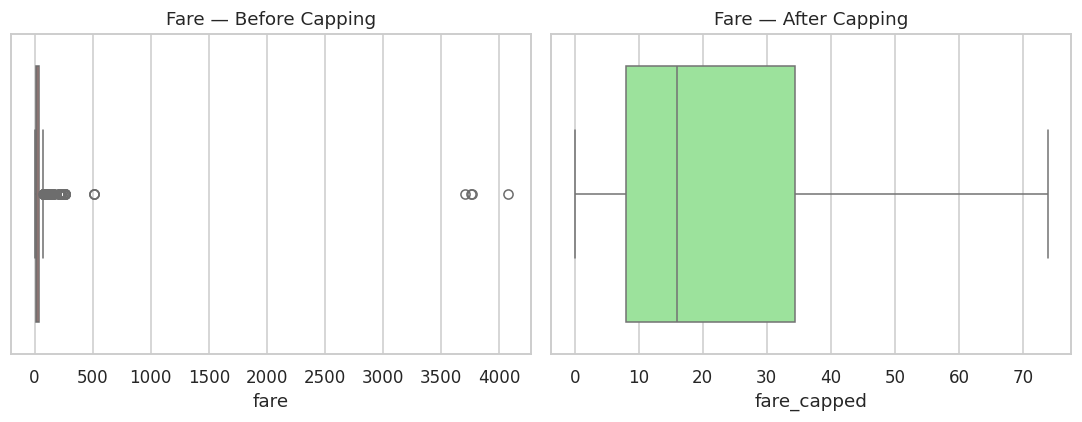

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=df["fare"], ax=axes[0], color="salmon")
axes[0].set_title("Fare — Before Capping")
sns.boxplot(x=df["fare_capped"], ax=axes[1], color="lightgreen")
axes[1].set_title("Fare — After Capping")
plt.tight_layout()
plt.show()

## 6. Exploratory Data Analysis

**Missing values map (raw data)** — visualizes where gaps existed before cleaning.

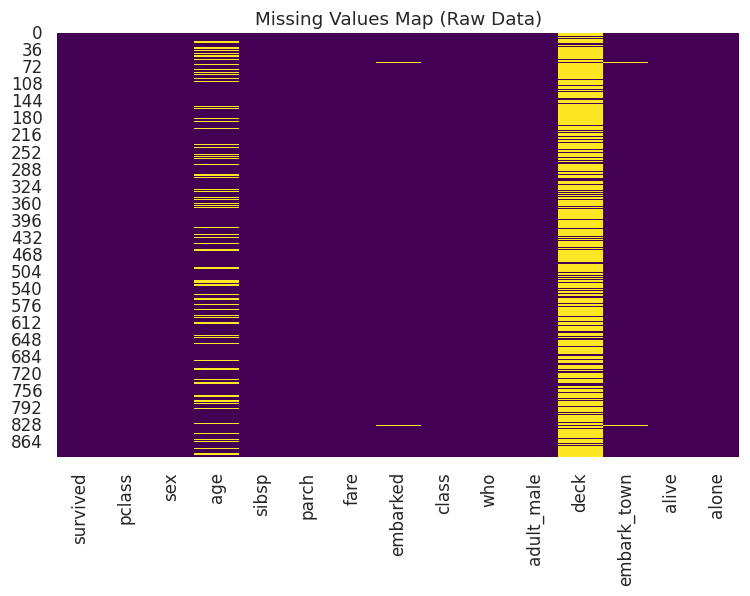

In [9]:
raw = pd.read_csv("data/titanic_raw.csv")
plt.figure(figsize=(8, 5))
sns.heatmap(raw.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Map (Raw Data)")
plt.show()

**Survival by sex** — women had a much higher survival rate than men.

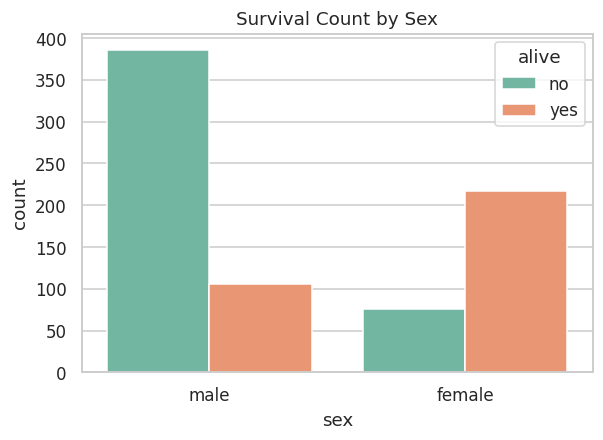

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex", hue="alive")
plt.title("Survival Count by Sex")
plt.show()

**Survival rate by passenger class** — 1st class passengers survived at more than double the rate of 3rd class.

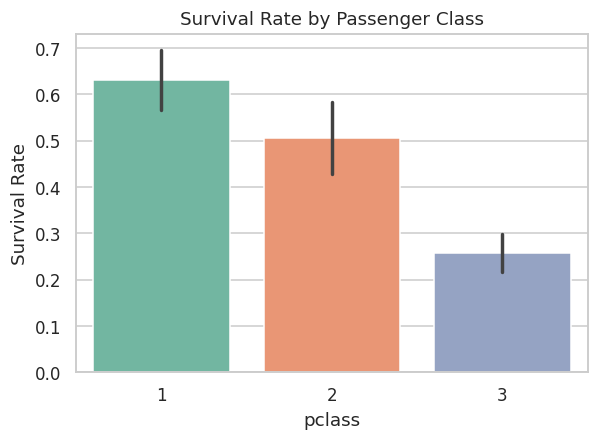

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="pclass", y="survived", hue="pclass", palette="Set2", legend=False)
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.show()

**Age distribution** — most passengers were between 20-40 years old.

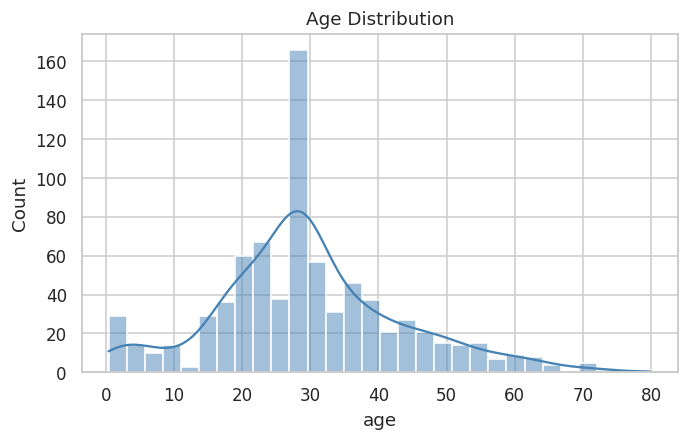

In [12]:
plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.show()

**Correlation heatmap** — relationships between numeric features.

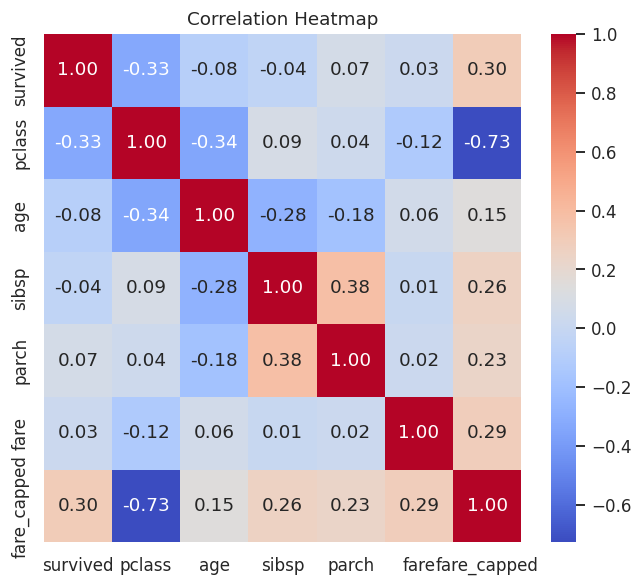

In [13]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(7, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 7. Summary Dashboard

A single view combining the key findings, suitable for a stakeholder report.

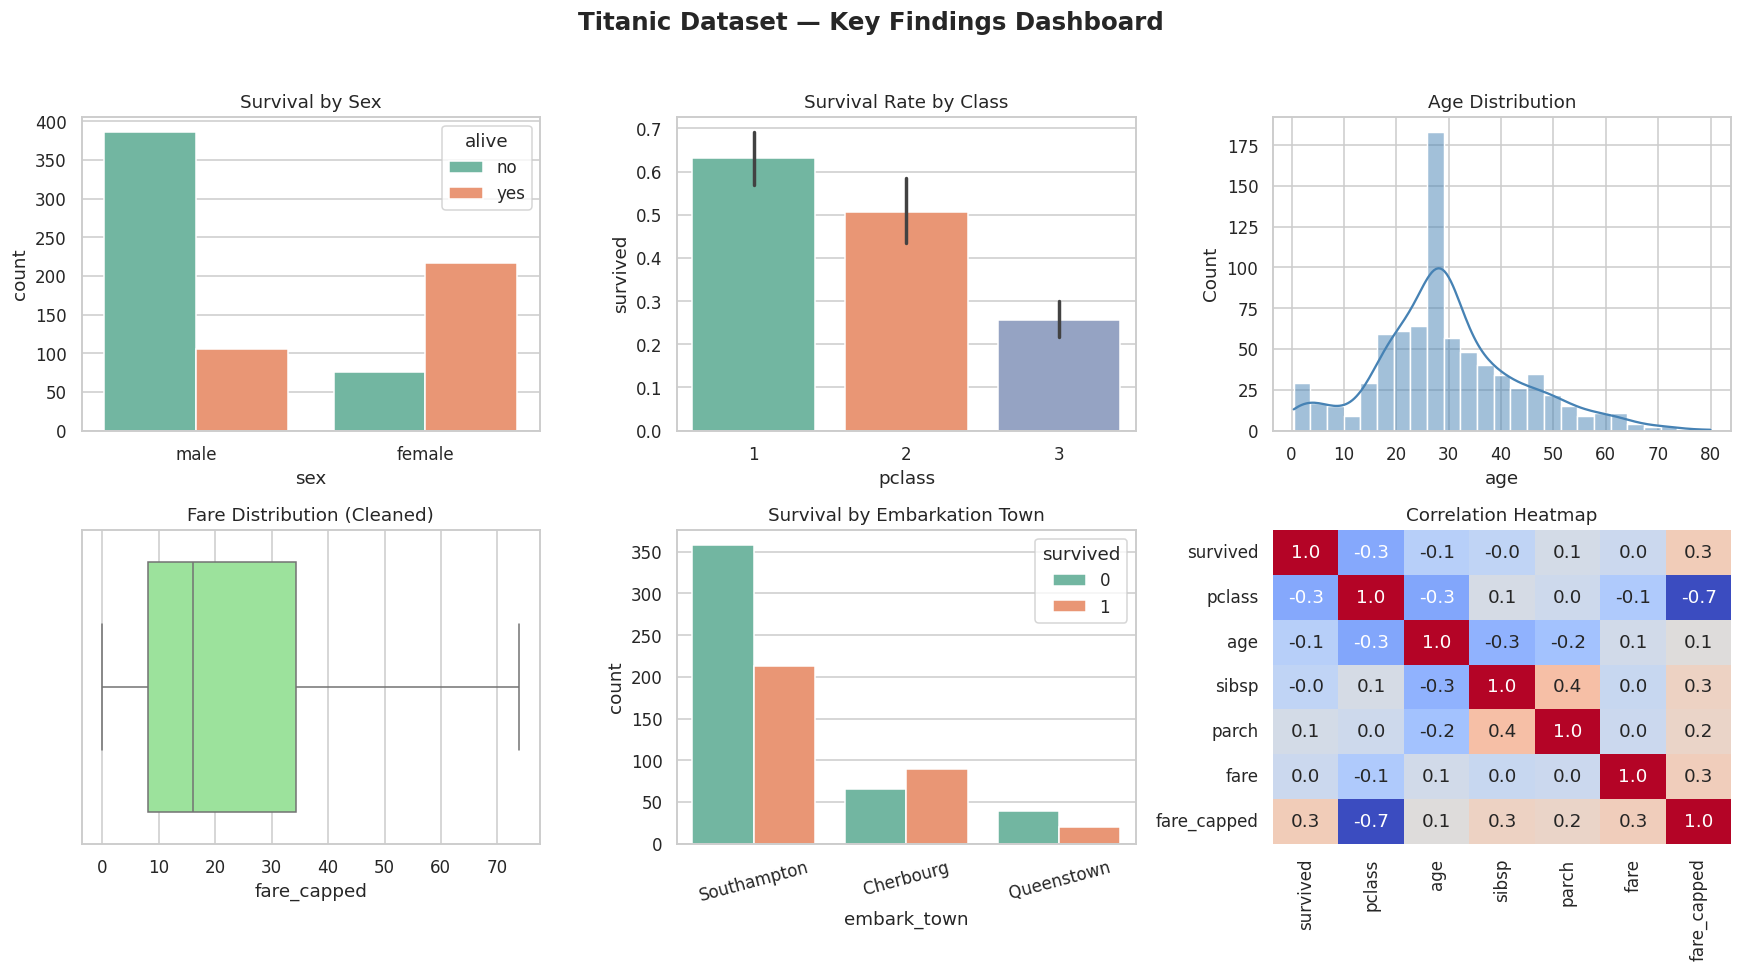

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Titanic Dataset — Key Findings Dashboard", fontsize=16, fontweight="bold")

sns.countplot(data=df, x="sex", hue="alive", ax=axes[0, 0])
axes[0, 0].set_title("Survival by Sex")

sns.barplot(data=df, x="pclass", y="survived", hue="pclass", palette="Set2", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Survival Rate by Class")

sns.histplot(df["age"], bins=25, kde=True, ax=axes[0, 2], color="steelblue")
axes[0, 2].set_title("Age Distribution")

sns.boxplot(x=df["fare_capped"], ax=axes[1, 0], color="lightgreen")
axes[1, 0].set_title("Fare Distribution (Cleaned)")

sns.countplot(data=df, x="embark_town", hue="survived", ax=axes[1, 1])
axes[1, 1].set_title("Survival by Embarkation Town")
axes[1, 1].tick_params(axis='x', rotation=15)

sns.heatmap(numeric_df.corr(), annot=True, fmt=".1f", cmap="coolwarm", ax=axes[1, 2], cbar=False)
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 8. Key Findings

- **Sex was the strongest survival predictor**: women survived at a far higher rate than men.
- **Class mattered**: 1st class passengers had roughly 2.5x the survival rate of 3rd class.
- **Age**: children had somewhat better survival odds; the bulk of passengers were young adults (20-40).
- **Fare correlates with class** (as expected) and mildly with survival, since fare is a proxy for class.
- **Data quality**: the raw data had duplicate rows, missing `age`/`embarked` values, a mostly-empty `deck` column, and a few extreme fare outliers — all handled above.

## 9. Save Cleaned Data

In [15]:
df.to_csv("outputs/titanic_cleaned.csv", index=False)
df.describe(include="all").T.to_csv("outputs/summary_statistics.csv")
print("Saved cleaned dataset and summary statistics to outputs/")

Saved cleaned dataset and summary statistics to outputs/
